# 06 · Fans, jetfoils, Coanda flow and jet enclosure aerodynamics

Where ATLAS's lift comes from: nine ducted fans whose jets are turned downward by curved jetfoils. This notebook covers the momentum theory of a fan in a duct, how the simulator models the turned jet and its losses, ram drag, what Coanda flow is and what the model leaves out, and how all of it reaches PX4's mixer.

In [1]:
# Setup: make the repository importable and load the V3 airframe used throughout these notebooks
import sys, math, pathlib
ROOT = pathlib.Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from airframe_designer.geometry.airframe import Airframe

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": 0.3})

AF_PATH = ROOT / "airframes" / "atlas_v3_v34_foils_50_65_50_tuned.json"
af = Airframe.load(AF_PATH)
af.resolve_mass()
G = 9.80665
print(f"{af.name}: {af.mass.mass:.2f} kg, {len(af.active_rotors())} fans, hover pitch {af.hover_pitch_deg} deg, parked {af.landed_pitch_deg} deg")

ATLAS_V3_V34_FOILS_50_65_50_TUNED: 11.83 kg, 9 fans, hover pitch 23.85 deg, parked 23.85 deg


In [2]:
from airframe_designer.aero.rotor_aero import RotorSet
rs = RotorSet(af.active_rotors(), af.cg)
print(f"{'fan':10s} {'kind':7s} {'D (mm)':>6s} {'Tmax':>5s} {'exit':>6s} {'T_eff':>6s} {'km':>6s} {'tau':>5s} ram")
for r in af.active_rotors():
    print(f"{r.name[:10]:10s} {r.kind:7s} {r.diameter * 1000:6.0f} {r.max_thrust:5.1f} {r.deflection_deg():6.1f} {r.effective_max_thrust():6.2f} {r.km:6.3f} {r.tau:5.2f} {r.ram_drag}")

fan        kind    D (mm)  Tmax   exit  T_eff     km   tau ram
M1         ducted      96  36.0   50.0  34.00  0.002  0.12 True
M2         ducted      96  36.0   50.0  34.00  0.002  0.12 True
M3         ducted      96  36.0   65.0  33.40  0.002  0.12 True
M4         ducted      96  36.0   65.0  33.40  0.002  0.12 True
M5         ducted      96  36.0   50.0  34.00  0.002  0.12 True
M6         ducted      96  36.0   50.0  34.00  0.002  0.12 True
M7         ducted      80  36.0    0.0  36.00  0.002  0.12 True
M8         ducted      80  36.0    0.0  36.00  0.002  0.12 True
M9         ducted      80  36.0    0.0  36.00  0.002  0.12 True


## 1. Jet enclosure: momentum theory for a ducted fan

**Theory.** Treat the fan as an actuator disc of area $A$ adding momentum to air drawn from rest. Thrust is the momentum flux leaving the system, $T = \dot m V_e$ with $\dot m = \rho A_e V_e$. With exit area ratio $\sigma = A_e/A$:

$$T = \rho\,\sigma A\,V_e^2,\qquad P_{\text{ideal}} = \tfrac12\dot m V_e^2 = \frac{T^{3/2}}{2\sqrt{\rho\,\sigma A}},\qquad \text{open rotor: } P_{\text{ideal}} = \frac{T^{3/2}}{\sqrt{2\rho A}}.$$

> **Note: what the duct buys**
>
> An open propeller's wake contracts to half the disc area, so the air leaves faster than it needs to and wastes energy. A duct with an exit as big as the disc ($\sigma = 1$) stops that contraction: for the same thrust it needs about 71 % of the power, or for the same power it gives about 26 % more thrust. Part of that extra thrust is suction on the duct lip. In the simulator thrust is specified per fan, so this formula is only used as a power diagnostic.

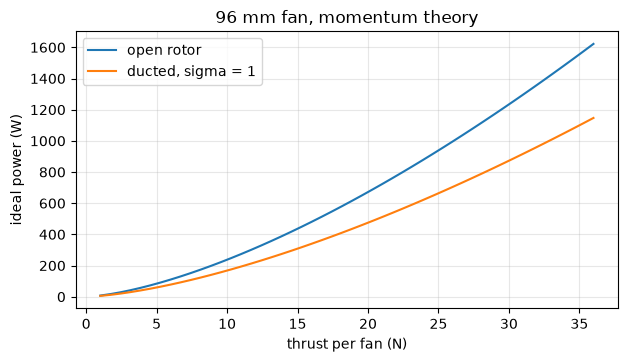

at ~12.9 N per fan: open 348 W, ducted 246 W (ideal); exit speed 38 m/s


In [3]:
rho = 1.225
r0 = af.active_rotors()[0]; A = r0.disc_area
T = np.linspace(1, r0.max_thrust, 50)
P_open = T**1.5 / np.sqrt(2 * rho * A); P_duct = T**1.5 / (2 * np.sqrt(rho * A))
plt.plot(T, P_open, label="open rotor"); plt.plot(T, P_duct, label="ducted, sigma = 1")
plt.xlabel("thrust per fan (N)"); plt.ylabel("ideal power (W)"); plt.legend(); plt.title(f"{r0.diameter * 1000:.0f} mm fan, momentum theory"); plt.show()
T_h = af.mass.mass * G / len(af.active_rotors())
print(f"at ~{T_h:.1f} N per fan: open {T_h**1.5 / np.sqrt(2 * rho * A):.0f} W, ducted {T_h**1.5 / (2 * np.sqrt(rho * A)):.0f} W (ideal); exit speed {math.sqrt(T_h / (rho * A)):.0f} m/s")

## 2. The turned jet: direction, loss and point of action

**Theory.** The jetfoil turns the jet by its exit angle $\delta$. The simulator models:

$$\hat{\mathbf a} = (\cos\delta,\ 0,\ -\sin\delta),\qquad \text{lean} = 90^\circ - \delta,\qquad T_{\text{eff}} = T_{\max}\,\max\Big(0,\ 1 - k_{\text{turn}}\frac{\delta}{90^\circ}\Big),\ \ k_{\text{turn}} = 0.1,$$

acting at the jet exit line $\mathbf r = \mathbf r_{\text{TE}} + h\hat{\mathbf n}$ with $h = 15$ mm. The exit angle comes from the CAD: rays cast through the foil every 2.5 mm, slope of the last 5 mm of wall.

> **Note: why one force at the exit is enough**
>
> Draw a box around the fan, duct and foil. Air enters from rest and leaves as a jet along the trailing edge. By momentum balance, the total force on everything inside the box equals the jet's momentum flux, pointing opposite to where the jet leaves. So the fan's own thrust and the foil's reaction never need to be modelled separately: only their sum, the turned jet, acting where the jet leaves.

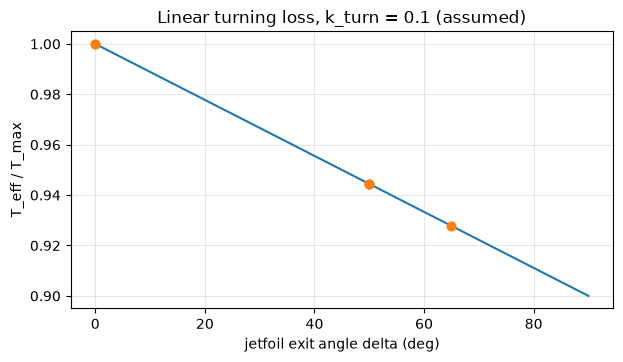

M1         delta  50.0 deg  lean  40.0 deg  axis [ 0.643  0.    -0.766]  loss 5.6 %
M2         delta  50.0 deg  lean  40.0 deg  axis [ 0.643  0.    -0.766]  loss 5.6 %
M3         delta  65.0 deg  lean  25.0 deg  axis [ 0.423  0.    -0.906]  loss 7.2 %


In [4]:
d = np.linspace(0, 90, 91)
plt.plot(d, 1 - 0.1 * d / 90)
for r in af.active_rotors():
    plt.plot(r.deflection_deg(), r.effective_max_thrust() / r.max_thrust, "o", color="C1")
plt.xlabel("jetfoil exit angle delta (deg)"); plt.ylabel("T_eff / T_max"); plt.title("Linear turning loss, k_turn = 0.1 (assumed)"); plt.show()
for r in af.active_rotors()[:3]:
    dl = r.deflection_deg()
    print(f"{r.name[:10]:10s} delta {dl:5.1f} deg  lean {90 - dl:5.1f} deg  axis {np.round(np.asarray(r.axis) / np.linalg.norm(r.axis), 3)}  loss {100 * (1 - r.effective_max_thrust() / r.max_thrust):.1f} %")

## 3. Coanda flow: how a curved wall turns a jet

**Theory.** For streamlines to curve around a wall of radius $R$, the pressure must drop towards the wall. A radial momentum balance across a jet of thickness $b$ and speed $U$ gives

$$\frac{\partial p}{\partial n} = \frac{\rho U^2}{R}\quad\Rightarrow\quad \Delta p \approx \frac{\rho U^2 b}{R}.$$

The jet stays attached while that suction survives wall friction and mixing with the surrounding air. Thin, fast jets on gentle curves (large $R/b$) turn further before they separate.

> **Note: what the simulator assumes about Coanda flow**
>
> The simulator assumes the jet stays fully attached and leaves exactly along the trailing edge, at every throttle and airspeed. If the real jet separates early, it leaves at a smaller angle than the wall: more forward thrust, less lift, a different hover pitch. Separation, jet spreading, entrainment, jet-jet interaction and ground effect are not modelled. The numbers in the next cell are an order-of-magnitude illustration with an assumed wall radius, not a measurement.

In [5]:
U = math.sqrt(T_h / (rho * A))          # jet speed from momentum theory at hover thrust
b = 2 * 0.015                            # jet thickness ~ nozzle height (twice the 15 mm half-height used in the model)
for R_wall in (0.05, 0.10, 0.20):        # assumed wall radii
    print(f"R = {R_wall:.2f} m, R/b = {R_wall / b:4.1f}: suction at the wall ~ {rho * U**2 * b / R_wall:5.0f} Pa  (jet speed {U:.0f} m/s)")

R = 0.05 m, R/b =  1.7: suction at the wall ~  1069 Pa  (jet speed 38 m/s)
R = 0.10 m, R/b =  3.3: suction at the wall ~   534 Pa  (jet speed 38 m/s)
R = 0.20 m, R/b =  6.7: suction at the wall ~   267 Pa  (jet speed 38 m/s)


## 4. Ram drag: the enclosure in a crossflow

**Theory.** Air arriving at the fan with velocity $\mathbf V$ must be turned into the fan's own jet, which costs momentum flux $\dot m\mathbf V$:

$$\mathbf f_{\text{ram},i} = -\dot m_i\mathbf V_i,\qquad \dot m_i = \sqrt{\rho A_i T_i},\qquad \mathbf V_i = \mathbf v_{\text{air}} + \boldsymbol\omega\times\mathbf r_i .$$

> **Note: why ram drag also slows yaw**
>
> Ram drag grows with the air speed seen by each fan, including the part caused by the aircraft's own rotation ($\boldsymbol\omega\times\mathbf r$). So it resists translation and rotation alike. At 2 m/s it is about 0.7 N per fan, roughly 6 N in total against 116 N of weight; it also damps yaw, which is part of why ATLAS's yaw is sluggish.

In [6]:
omega_h = np.full(rs.n, math.sqrt(T_h / rs.tmax.mean()))
F0, M0, _, _ = rs.forces(omega_h, np.zeros(3), np.zeros(3))
for v in (1.0, 2.0, 4.0):
    F, M, _, _ = rs.forces(omega_h, np.array([v, 0, 0]), np.zeros(3))
    print(f"forward airspeed {v:.0f} m/s: ram drag change {np.round(F - F0, 2)} N")
F, M, _, _ = rs.forces(omega_h, np.zeros(3), np.array([0, 0, 0.5]))
print("yaw rate 0.5 rad/s: yaw moment change", round((M - M0)[2], 3), "N m")

forward airspeed 1 m/s: ram drag change [-2.87  0.    0.  ] N
forward airspeed 2 m/s: ram drag change [-5.74  0.    0.  ] N
forward airspeed 4 m/s: ram drag change [-11.48   0.     0.  ] N
yaw rate 0.5 rad/s: yaw moment change -0.374 N m


## 5. Into PX4: the mixer export and the hover trim

**Theory.** PX4's control allocation uses, per fan, the moment and force per unit thrust in hover axes: the effectiveness column $[\mathbf p\times\hat{\mathbf a} - k_m\hat{\mathbf a};\ \hat{\mathbf a}]$, and a relative thrust coefficient `CA_ROTORi_CT` $\propto T_{\text{eff},i}$. The hover pitch $\theta_h$ is chosen by scanning for the angle that leaves the most control headroom, and `MPC_THR_HOVER` is the throttle that balances the weight.

In [7]:
p = af.px4_params()
for i in range(3):
    print({k: p[k] for k in p if k.startswith(f"CA_ROTOR{i}_")})
print("SENS_BOARD_Y_OFF =", p["SENS_BOARD_Y_OFF"], "  hover throttle fraction =", round(af.hover_thrust_fraction(), 3))
B = af.effectiveness()
print("effectiveness matrix (rows: roll, pitch, yaw moment; x, y, z force), columns = fans:\n", np.round(B, 3))
print("trim hover pitch from the scan:", af.trim_hover_pitch(), "deg")

{'CA_ROTOR0_PX': -0.2888, 'CA_ROTOR0_PY': -0.409, 'CA_ROTOR0_PZ': 0.4481, 'CA_ROTOR0_AX': 0.2782, 'CA_ROTOR0_AY': 0.0, 'CA_ROTOR0_AZ': -0.9605, 'CA_ROTOR0_KM': 0.002, 'CA_ROTOR0_CT': 6.139}
{'CA_ROTOR1_PX': -0.2888, 'CA_ROTOR1_PY': 0.417, 'CA_ROTOR1_PZ': 0.4481, 'CA_ROTOR1_AX': 0.2782, 'CA_ROTOR1_AY': 0.0, 'CA_ROTOR1_AZ': -0.9605, 'CA_ROTOR1_KM': 0.002, 'CA_ROTOR1_CT': 6.139}
{'CA_ROTOR2_PX': -0.2939, 'CA_ROTOR2_PY': -0.3064, 'CA_ROTOR2_PZ': 0.3751, 'CA_ROTOR2_AX': 0.0201, 'CA_ROTOR2_AY': 0.0, 'CA_ROTOR2_AZ': -0.9998, 'CA_ROTOR2_KM': 0.002, 'CA_ROTOR2_CT': 6.031}
SENS_BOARD_Y_OFF = 23.85   hover throttle fraction = 0.404
effectiveness matrix (rows: roll, pitch, yaw moment; x, y, z force), columns = fans:
 [[ 0.392 -0.401  0.306 -0.314  0.195 -0.204  0.156 -0.161 -0.003]
 [-0.153 -0.153 -0.286 -0.286 -0.203 -0.203  0.371  0.373  0.52 ]
 [ 0.116 -0.114  0.008 -0.004  0.059 -0.057  0.168 -0.162  0.003]
 [ 0.278  0.278  0.02   0.02   0.278  0.278 -0.35  -0.35  -0.404]
 [ 0.     0.     0.  

trim hover pitch from the scan: 23.85 deg


> **Note: what is still an assumption**
>
> Fan maximum thrust (36 N), reaction torque coefficient $k_m = 0.002$, spool time constant (0.12 s), turning loss $k_{\text{turn}} = 0.1$ and nozzle height (15 mm) are all unmeasured. A thrust stand with a 6-axis load cell, one fan with its foil, swept in throttle, would replace all five in one setup.